# Introduction to Analytical Tables

The cron process makes a number of tables available for analysis. These tables are updated at the beginning of each day. 

| Table      | Description      |
| ------------- | ------------- |
| sensor_readings | The most "raw" data from the Coris API. One row per Sensor and UTC timestamp. Devices have 2 Sensors, one for Temperature and one for Humidity so each Device will typically have two rows per UTC timestamp. |
| device_readings | Sensor readings reorganized to one row per Device and UTC timestamp, with Sensor measurements across columns instead of rows. |
| sensors | Information about the unique sensors. One row per SensorID_Coris. Includes information extracted from SensorName. Join this to sensor_readings during analysis to enhance with Building, Room, Direction, etc. |
| devices | Information about unique devices. One row per DeviceID_Coris. Includes information extracted from SensorName. Join this to device_readings during analysis to enhance with Building, Room, Direction, etc. |
| utcs | Information related to the UTC times in various datasets. Join to sensor_readings or device_readings to enhance with Date, Time, Year, Hour, Weekday, etc. |
| sensor_readings_daily | Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries. You can create different cubes to support common analysis patterns. |
| device_readings_daily | Example of device readings summarized to the daily level. |

Let's take a look at each of the tables. 

In [1]:
import duckdb
duckdb.sql("SELECT * FROM read_parquet('../data/sensor_readings.parquet') LIMIT 5").df()

,SensorReadingUTC,QueryUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,SensorReadingUTC_SecondsFromPrior,Historical
0,1764258135,1764862382,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,conserv:333:c008706:RH,RH,NaN,50.869999,<NA>,True
1,1764259035,1764862382,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,conserv:333:c008706:RH,RH,NaN,49.540001,<NA>,True
2,1764259935,1764862382,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,conserv:333:c008706:RH,RH,NaN,48.720001,<NA>,True
3,1764260835,1764862382,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,conserv:333:c008706:RH,RH,NaN,49.470001,<NA>,True
4,1764261735,1764862382,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,conserv:333:c008706:RH,RH,NaN,48.970001,<NA>,True


In [2]:
duckdb.sql("""
    SELECT * 
    FROM read_parquet('../data/sensor_readings.parquet') 
    WHERE Historical = false AND SensorID = 'conserv:333:c008706:RH'
""").df()

,SensorReadingUTC,QueryUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,SensorReadingUTC_SecondsFromPrior,Historical
0,1764862939,1764863423,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,conserv:333:c008706:RH,RH,NaN,50.77,<NA>,False


In [3]:
duckdb.sql("SELECT * FROM read_parquet('../data/device_readings.parquet') LIMIT 5").df()

,Source,DeviceID,DeviceName,Sensors,SensorNames,SensorTypes,SensorReadingUTC,QueryUTC,Historical,SensorReadingF,SensorReadingRh
0,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH|conserv:333:c008706:Tem...,conserv:333:c008706:RH|conserv:333:c008706:Tem...,RH|Temperature,1764258135,1764862382,True,69.673996,50.869999
1,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH|conserv:333:c008706:Tem...,conserv:333:c008706:RH|conserv:333:c008706:Tem...,RH|Temperature,1764259035,1764862382,True,69.584000,49.540001
2,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH|conserv:333:c008706:Tem...,conserv:333:c008706:RH|conserv:333:c008706:Tem...,RH|Temperature,1764259935,1764862382,True,69.619995,48.720001
3,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH|conserv:333:c008706:Tem...,conserv:333:c008706:RH|conserv:333:c008706:Tem...,RH|Temperature,1764260835,1764862382,True,69.710007,49.470001
4,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH|conserv:333:c008706:Tem...,conserv:333:c008706:RH|conserv:333:c008706:Tem...,RH|Temperature,1764261735,1764862382,True,69.962006,48.970001


In [4]:
duckdb.sql("SELECT * FROM read_parquet('../data/sensors.parquet') LIMIT 5").df()

,Source,SensorID,SensorName,SensorType,DeviceID
0,Conserv,conserv:333:c008706:RH,conserv:333:c008706:RH,RH,conserv:333:c008706
1,Conserv,conserv:333:c008706:Temperature,conserv:333:c008706:Temperature,Temperature,conserv:333:c008706
2,Conserv,conserv:333:c008733:RH,conserv:333:c008733:RH,RH,conserv:333:c008733
3,Conserv,conserv:333:c008733:Temperature,conserv:333:c008733:Temperature,Temperature,conserv:333:c008733
4,Conserv,conserv:333:c008734:RH,conserv:333:c008734:RH,RH,conserv:333:c008734


In [5]:
duckdb.sql("SELECT * FROM read_parquet('../data/devices.parquet') LIMIT 5").df()

,Source,DeviceID,DeviceName,SensorIDs,SensorNames,SensorTypes
0,Conserv,conserv:333:c009072,BBARCH0100001_______,conserv:333:c009072:RH|conserv:333:c009072:Tem...,conserv:333:c009072:RH|conserv:333:c009072:Tem...,RH|Temperature
1,Conserv,conserv:333:c009073,BBARCHB100116_______,conserv:333:c009073:RH|conserv:333:c009073:Tem...,conserv:333:c009073:RH|conserv:333:c009073:Tem...,RH|Temperature
2,Conserv,conserv:333:c009081,BCSC__01H103________,conserv:333:c009081:RH|conserv:333:c009081:Tem...,conserv:333:c009081:RH|conserv:333:c009081:Tem...,RH|Temperature
3,Conserv,conserv:333:c009096,BFAST__BS___________,conserv:333:c009096:RH|conserv:333:c009096:Tem...,conserv:333:c009096:RH|conserv:333:c009096:Tem...,RH|Temperature
4,Conserv,conserv:333:c009025,BYCBA_0100101_N_____,conserv:333:c009025:RH|conserv:333:c009025:Tem...,conserv:333:c009025:RH|conserv:333:c009025:Tem...,RH|Temperature


In [6]:
duckdb.sql("SELECT * FROM read_parquet('../data/utcs.parquet') LIMIT 5").df()

,UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
0,1764360204,2025-11-28 13:03:24,2025-11-28 06:03:24-07:00,2025-11-28,08:03:24,2025,11,Friday,5,8,8,AM
1,1764622350,2025-12-01 13:52:30,2025-12-01 06:52:30-07:00,2025-12-01,08:52:30,2025,12,Monday,1,8,8,AM
2,1764753439,2025-12-03 02:17:19,2025-12-02 19:17:19-07:00,2025-12-02,21:17:19,2025,12,Tuesday,2,21,9,PM
3,1764753463,2025-12-03 02:17:43,2025-12-02 19:17:43-07:00,2025-12-02,21:17:43,2025,12,Tuesday,2,21,9,PM
4,1764753476,2025-12-03 02:17:56,2025-12-02 19:17:56-07:00,2025-12-02,21:17:56,2025,12,Tuesday,2,21,9,PM


In [7]:
duckdb.sql("SELECT * FROM read_parquet('../data/sensor_readings_daily.parquet') LIMIT 5").df()

,Source,date,SensorID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,Conserv,2025-12-04,conserv:333:c008733:RH,1,0.000000,43.759998,NaN,43.759998,NaN,43.759998
1,Conserv,2025-12-04,conserv:333:c008733:Temperature,1,69.854004,0.000000,69.854004,NaN,69.854004,NaN
2,Conserv,2025-12-04,conserv:333:c008734:RH,2,0.000000,89.199997,NaN,44.220001,NaN,44.980000
3,Conserv,2025-12-04,conserv:333:c008734:Temperature,2,138.808014,0.000000,69.386002,NaN,69.422005,NaN
4,Conserv,2025-12-04,conserv:333:c008784:RH,1,0.000000,44.549999,NaN,44.549999,NaN,44.549999


In [8]:
duckdb.sql("SELECT * FROM read_parquet('../data/device_readings_daily.parquet') LIMIT 5").df()

,Source,date,DeviceID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,Conserv,2025-12-04,conserv:333:c008733,1,69.854004,43.759998,69.854004,43.759998,69.854004,43.759998
1,Conserv,2025-12-04,conserv:333:c008734,2,138.808014,89.199997,69.386002,44.220001,69.422005,44.980000
2,Conserv,2025-12-04,conserv:333:c008784,1,69.566002,44.549999,69.566002,44.549999,69.566002,44.549999
3,Conserv,2025-12-04,conserv:333:c008785,2,138.574005,90.539993,69.223999,44.919998,69.350006,45.619999
4,Conserv,2025-12-04,conserv:333:c008786,2,140.373993,95.029999,70.070000,47.299999,70.304001,47.730000


# Sample Queries

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

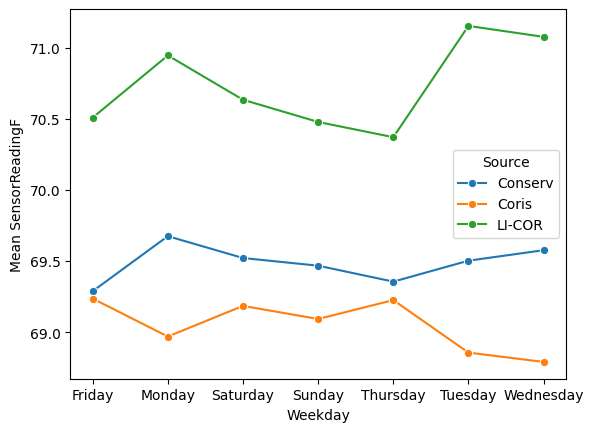

In [9]:
# Example: Average reading by Weekday. 

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# use abs(dr.SensorReadingUTC - dr.QueryUTC) < 60 * 5 to remove old sensor readings.

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, Source, avg(SensorReadingF) as 'Mean SensorReadingF'
    FROM read_parquet('../data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('../data/utcs.parquet') AS u ON 
        dr.SensorReadingUTC = u.UTC
    GROUP BY day_of_week, Source
    ORDER BY day_of_week, Source
""").df()

sns.lineplot(x='Weekday', y='Mean SensorReadingF', hue='Source', data=data, marker='o')

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

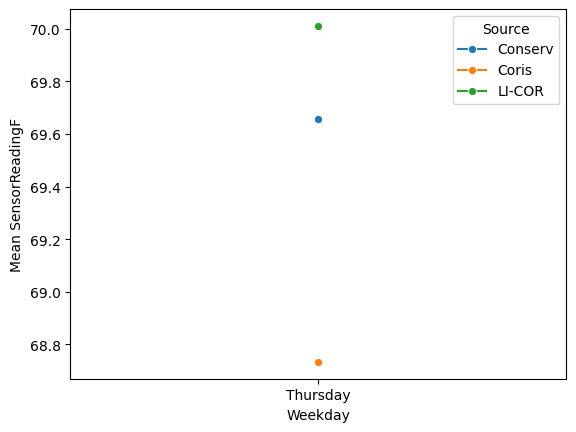

In [10]:
# Example: Average reading by Weekday - using the cubes.

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# cubes already have old sensor readings removed. 

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, Source, sum(SensorReadingF_sum) / sum(row_count) as 'Mean SensorReadingF'
    FROM read_parquet('../data/device_readings_daily.parquet') AS drd
    INNER JOIN (SELECT DISTINCT date, day_of_week FROM read_parquet('../data/utcs.parquet')) AS u
        ON drd.date = u.date
    GROUP BY day_of_week, Source
    ORDER BY day_of_week, Source
""").df()

# need DISTINCT on utcs to prevent duplication!

sns.lineplot(x='Weekday', y='Mean SensorReadingF', hue='Source', data=data, marker='o')

In [11]:
# Readings that differ from the Query UTC. These could be data errors if the difference is large.
duckdb.sql("""
    SELECT QueryUTC, SensorReadingUTC, (SensorReadingUTC - QueryUTC) / 60 as 'Difference (Minutes)'
    FROM read_parquet('../data/sensor_readings.parquet') 
    WHERE abs(SensorReadingUTC - QueryUTC) > 60 * 1 AND Historical = False
    ORDER BY abs(SensorReadingUTC - QueryUTC) DESC
""").df()

,QueryUTC,SensorReadingUTC,Difference (Minutes)
0,1764863423,1764862529,-14.900000
1,1764863423,1764862529,-14.900000
2,1764863423,1764862575,-14.133333
3,1764863423,1764862575,-14.133333
4,1764863423,1764862582,-14.016667
5,1764863423,1764862582,-14.016667
6,1764863423,1764862632,-13.183333
7,1764863423,1764862632,-13.183333
8,1764863423,1764862649,-12.900000
9,1764863423,1764862649,-12.900000
